# Config

FOA baseline với `epsilon=16`, `alpha=1`, `K=10`, 300 bước mặc định. Các sửa chữa trong bản này giữ nguyên objective/update của tác giả; bổ sung pin dependency, kiểm tra số hữu hạn và kiểm chứng nhánh crop. Xem [review](../../docs/kltn_attack_v1_1_review.md).

Kaggle: restart session, chạy từ đầu. `kmeans-pytorch==0.3` trên PyPI thiếu `iter_limit`; notebook cài commit upstream cố định có hỗ trợ tham số này. Không bỏ `iter_limit=100` khỏi loss để né lỗi phiên bản. Commit dependency này phục vụ tương thích, không khẳng định là phiên bản trong môi trường paper ban đầu.


In [ ]:
# Cell 1 — Parameters. Change experimental values here only.
from pathlib import Path

DATASET_ROOT = Path('/kaggle/input/datasets/zintom/blackbox-adversarial-attack-dataset')
WORK_ROOT = Path('/kaggle/working')
REPO_DIR = WORK_ROOT / 'FOA-Attack'
OUTPUT_DIR = WORK_ROOT / 'foa_attack_output'
HF_HOME = WORK_ROOT / 'hf_cache'

# Official implementation used for parity. Its resolved revision is recorded automatically.
FOA_REPO_URL = 'https://github.com/jiaxiaojunQAQ/FOA-Attack.git'

In [ ]:
# Paper defaults
PAPER_NUM_SAMPLES = 100
PAPER_STEPS = 300
PAPER_EPSILON = 16.0       # pixel space [0, 255]
PAPER_ALPHA = 1.0          # pixel space [0, 255]
PAPER_INPUT_RES = 224
PAPER_CROP_SCALE = (0.5, 0.9)
PAPER_BACKBONES = ('B16', 'B32', 'Laion')
PAPER_CLUSTER_NUMBER = 10
PAPER_SEED = 2023

# Experiment settings; explicit arguments in run_foa_attack use these current values.
NUM_SAMPLES = 10          # None: all available source/target pairs.
STEPS = 300
USE_SOURCE_CROP = True
USE_TARGET_CROP = True
DEVICE = 'cuda:0'
KMEANS_REVISION = 'f7f36bd1cb4e3a761d73d584866d0a9c6b4d2805'

assert DATASET_ROOT.exists(), 'Add Kaggle dataset: zintom/blackbox-adversarial-attack-dataset'
assert NUM_SAMPLES is None or (type(NUM_SAMPLES) is int and NUM_SAMPLES > 0)
assert type(STEPS) is int and STEPS > 0
print(f'Dataset: {DATASET_ROOT}\nOutput: {OUTPUT_DIR}\nDevice: {DEVICE}')


# Install package

In [ ]:
# Cell 2 — Kaggle dependency command. Re-run after changing the Kaggle image.
import sys, subprocess
packages = [
    'transformers==4.49.0', 'tokenizers==0.21.0', 'huggingface-hub==0.28.1',
    'hydra-core==1.3.2', 'omegaconf==2.3.0', 'pytorch-lightning==2.5.0.post0',
    'wandb==0.19.1', 'ftfy==6.3.1',
    'numba',  # Upstream kmeans imports SoftDTW/numba even for Euclidean distance.
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir', *packages], check=True)
print('Dependencies installed. Restart the Kaggle session if pip reports a Torch/Torchvision conflict.')

In [ ]:
# Pin compatible upstream code; PyPI 0.3 lacks iter_limit.
# Do not silently reuse an already imported module after pip replaces its files.
if 'kmeans_pytorch' in sys.modules:
    raise RuntimeError('Restart the Kaggle session, then Run All to load the pinned kmeans implementation.')
KMEANS_PACKAGE = f'kmeans-pytorch @ git+https://github.com/subhadarship/kmeans_pytorch.git@{KMEANS_REVISION}'
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '--no-cache-dir',
    '--force-reinstall', '--no-deps', KMEANS_PACKAGE,
], check=True)


# Clone Github

In [ ]:
# Cell 3 — Fetch the original implementation and record source provenance.
# Reuse an existing checkout rather than deleting it on every Run All.
import os, shutil, subprocess, sys
os.environ.update({'HF_HOME': str(HF_HOME), 'WANDB_MODE': 'disabled', 'TOKENIZERS_PARALLELISM': 'false'})
if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', '--depth', '1', FOA_REPO_URL, str(REPO_DIR)], check=True)
elif not (REPO_DIR / '.git').is_dir():
    raise RuntimeError(f'REPO_DIR exists but is not a Git checkout: {REPO_DIR}')
else:
    origin = subprocess.check_output(['git', '-C', str(REPO_DIR), 'remote', 'get-url', 'origin'], text=True).strip()
    if origin.rstrip('/') != FOA_REPO_URL.rstrip('/'):
        raise RuntimeError(f'Existing checkout has a different origin: {origin}')
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
FOA_SOURCE_REVISION = subprocess.check_output(['git', '-C', str(REPO_DIR), 'rev-parse', 'HEAD'], text=True).strip()
print('Official FOA source revision:', FOA_SOURCE_REVISION)


# Library

In [ ]:
# Cell 4 — Imports and reproducibility.
import json, random, hashlib, importlib.util, inspect
from importlib import metadata
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import numpy as np
from PIL import Image
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torchvision.utils import save_image
from tqdm.auto import tqdm
import kmeans_pytorch
from kmeans_pytorch import kmeans

if 'iter_limit' not in inspect.signature(kmeans).parameters:
    raise RuntimeError('Loaded kmeans lacks iter_limit. Restart session and rerun the pinned install cell.')
kmeans_dist = metadata.distribution('kmeans-pytorch')
kmeans_direct_url = json.loads(kmeans_dist.read_text('direct_url.json') or '{}')
if kmeans_direct_url.get('vcs_info', {}).get('commit_id') != KMEANS_REVISION:
    raise RuntimeError('kmeans distribution is not the pinned Git commit. Restart and rerun installation.')
KMEANS_RUNTIME = {
    'version': kmeans_dist.version, 'revision': KMEANS_REVISION,
    'module': kmeans_pytorch.__file__, 'signature': str(inspect.signature(kmeans)),
}
print('Kmeans:', KMEANS_RUNTIME)

from surrogates import (
    ClipB16FeatureExtractor, ClipB32FeatureExtractor, ClipLaionFeatureExtractor,
    EnsembleFeatureExtractor_ot, EnsembleFeatureLoss_OT_foa_attack, suppress_output,
)

def set_foa_seed(seed: int = PAPER_SEED) -> None:
    """Set the same random/CUDA determinism controls as the original FOA script."""
    random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

set_foa_seed()
assert torch.cuda.is_available(), 'Enable a Kaggle GPU accelerator.'
print('Torch:', torch.__version__, '| GPU:', torch.cuda.get_device_name(0))


# Data loader

In [8]:
# Cell 5 — Dataset discovery and preprocessing (editable research boundary).
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(path: Path) -> int:
    """Return recursive number of supported image files below ``path``."""
    return sum(p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS for p in path.rglob('*'))

def find_imagefolder(root: Path, expected_name: str) -> Path:
    """Find the largest ImageFolder named ``expected_name`` in a Kaggle dataset."""
    candidates = sorted((p for p in root.rglob(expected_name) if p.is_dir()), key=lambda p: -count_images(p))
    if not candidates: raise FileNotFoundError(f'Cannot find {expected_name} below {root}')
    return candidates[0]

def pil_to_foa_tensor(image: Image.Image) -> Tensor:
    """Convert PIL RGB image to the original FOA tensor in pixel range [0, 255]."""
    array = np.array(image, np.uint8, copy=True)
    return torch.from_numpy(array).permute(2, 0, 1).contiguous().to(torch.get_default_dtype())


# Preprocessing
def preprocess_image(input_res: int = PAPER_INPUT_RES) -> transforms.Compose:
    """Build the exact Resize → CenterCrop → RGB → pixel-tensor preprocessing of FOA."""
    return transforms.Compose([
        transforms.Resize(input_res, interpolation=InterpolationMode.BICUBIC),
        transforms.CenterCrop(input_res), transforms.Lambda(lambda x: x.convert('RGB')),
        transforms.Lambda(pil_to_foa_tensor),
    ])

class ImageFolderWithPaths(datasets.ImageFolder):
    """ImageFolder that additionally returns the source image path for manifest export."""
    def __getitem__(self, index: int):
        """Return transformed image, class label, and original filesystem path."""
        image, label = super().__getitem__(index)
        return image, label, self.samples[index][0]

SOURCE_DIR, TARGET_DIR = find_imagefolder(DATASET_ROOT, 'bigscale'), find_imagefolder(DATASET_ROOT, 'target_images')
print('SOURCE_DIR:', SOURCE_DIR, count_images(SOURCE_DIR))
print('TARGET_DIR:', TARGET_DIR, count_images(TARGET_DIR))

SOURCE_DIR: /kaggle/input/datasets/zintom/blackbox-adversarial-attack-dataset/images/bigscale 1000
TARGET_DIR: /kaggle/input/datasets/zintom/blackbox-adversarial-attack-dataset/images/target_images 1000


# Visualize dataset

In [ ]:
# Preview helper is defined once below; keep preview RNG separate from attack RNG.


In [ ]:
# Use ImageFolder sample order, matching the actual attack loader; exclude directories/non-images.
source_image_path = [Path(path) for path, _ in datasets.ImageFolder(SOURCE_DIR).samples]
target_image_path = [Path(path) for path, _ in datasets.ImageFolder(TARGET_DIR).samples]


In [ ]:
import math
import matplotlib.pyplot as plt

def show_images(source_image_path, n=12, cols=4, random_sample=False, seed=42, figsize_per_image=(4, 4)):
    """
    Display images recursively from a folder.

    Args:
        folder: Path to image folder.
        n: Number of images to display.
        cols: Number of columns.
        random_sample: Randomly choose images if True.
        seed: Random seed.
        figsize_per_image: Size of each displayed image.
    """
    if len(source_image_path) == 0:
        return

    # image_paths = sorted(source_image_path)
    image_paths = source_image_path

    if random_sample:
        image_paths = random.Random(seed).sample(image_paths, min(n, len(image_paths)))
    else:
        image_paths = image_paths[:n]

    rows = math.ceil(len(image_paths) / cols)

    fig, axes = plt.subplots(rows,cols,
        figsize=(
            cols * figsize_per_image[0],
            rows * figsize_per_image[1]
        )
    )

    # Make axes always iterable
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, image_path in zip(axes, image_paths):
        image = Image.open(image_path).convert("RGB")

        ax.imshow(image)
        ax.set_title(image_path.name, fontsize=12)
        ax.axis("off")
    for ax in axes[len(image_paths):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Displayed: {len(image_paths)} images")

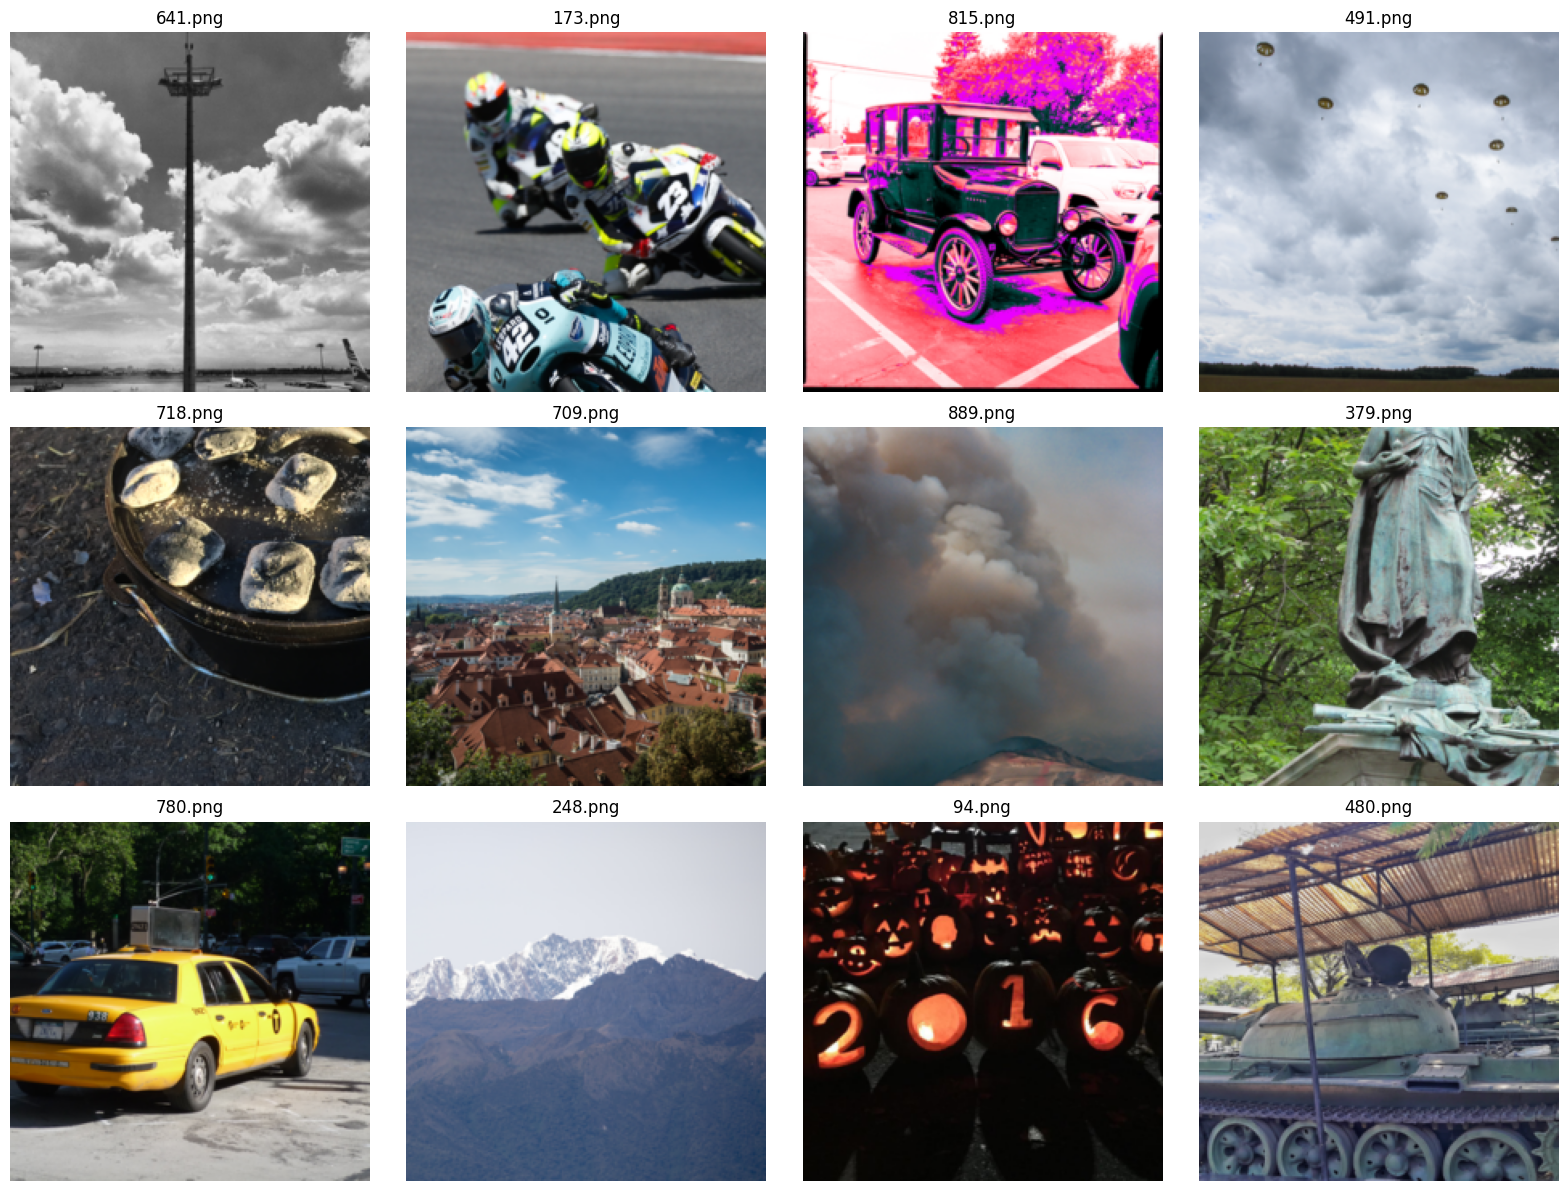

Displayed: 12 images


In [14]:
show_images(source_image_path)

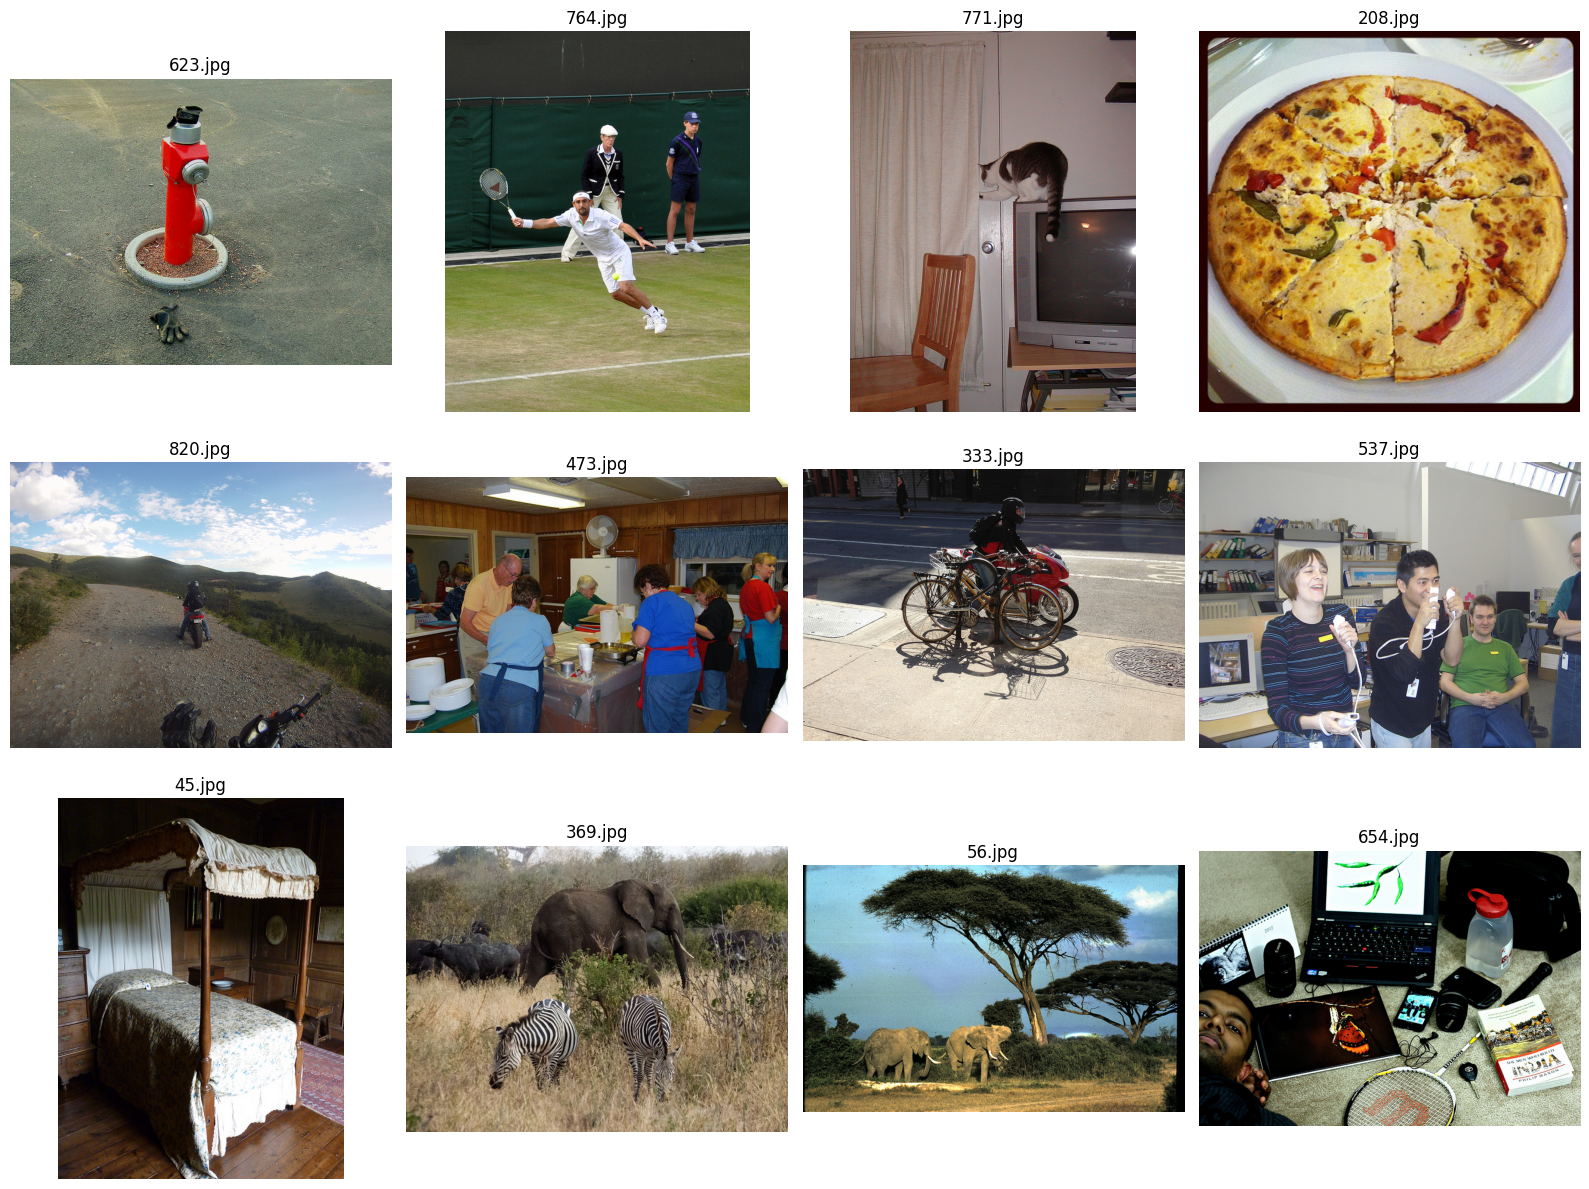

Displayed: 12 images


In [15]:
show_images(target_image_path)

In [18]:
# Cell 6 — FOA surrogate ensemble (unchanged original model choices).
BACKBONE_MAP = {'B16': ClipB16FeatureExtractor, 'B32': ClipB32FeatureExtractor, 'Laion': ClipLaionFeatureExtractor}

def build_foa_ensemble(backbones: Tuple[str, ...] = PAPER_BACKBONES, cluster_number: int = PAPER_CLUSTER_NUMBER):
    """Load original FOA surrogate extractors and its optimal-transport ensemble wrapper."""
    models = [BACKBONE_MAP[name]().eval().to(DEVICE).requires_grad_(False) for name in backbones]
    return EnsembleFeatureExtractor_ot(models, cluster_number=cluster_number), models

# Run only once; it downloads B16, B32 and LAION weights on the first Kaggle run.
ensemble_extractor, surrogate_models = build_foa_ensemble()
print('Loaded:', PAPER_BACKBONES)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/5.47G [00:00<?, ?B/s]

Loaded: ('B16', 'B32', 'Laion')


# Attacking

## Loss function

In [ ]:
# Cell 7 — FOA loss. This is the paper loss copied into an editable cell.
class FOAOptimalTransportLoss(nn.Module):
    """Original FOA global/local OT loss with its dynamic ensemble weighting (K=10 by default)."""
    def __init__(self, extractors: List[nn.Module], cluster_number: int = PAPER_CLUSTER_NUMBER):
        """Initialize FOA state for the frozen surrogate extractors and local cluster count."""
        super().__init__(); self.extractors = nn.ModuleList(extractors); self.cluster_number = cluster_number
        self.ground_truth, self.ground_truth_local, self.previous_loss_list = [], [], []

    @torch.no_grad()
    def set_ground_truth(self, x: Tensor) -> None:
        """Extract target global features and K-means local centers as FOA ground truth."""
        self.ground_truth.clear(); self.ground_truth_local.clear()
        for model in self.extractors:
            global_feature, local_feature = model.global_local_features(x.to(x.device))
            centers = self.cluster_centers(local_feature.squeeze(0), x.device).unsqueeze(0)
            self.ground_truth.append(global_feature); self.ground_truth_local.append(centers)

    def cluster_centers(self, embeddings: Tensor, device: torch.device) -> Tensor:
        """Compute original Euclidean K-means local centers (100 iteration limit)."""
        if embeddings.ndim != 2 or embeddings.shape[0] < self.cluster_number:
            raise ValueError('K-means needs a 2D embedding matrix with at least K rows.')
        if not torch.isfinite(embeddings).all():
            raise FloatingPointError('Non-finite target embeddings before K-means.')
        with suppress_output():
            _, centers = kmeans(X=embeddings, num_clusters=self.cluster_number, distance='euclidean', device=device, iter_limit=100)
        if not torch.isfinite(centers).all():
            raise FloatingPointError('K-means returned non-finite centers.')
        return centers.to(device)

    def optimal_transport(self, source: Tensor, target: Tensor) -> Tensor:
        """Return FOA cosine-similarity optimal-transport score using original Sinkhorn settings."""
        similarity = torch.einsum('md,nd->mn', F.normalize(source, dim=1), F.normalize(target, dim=1)).contiguous()
        u = torch.full((source.shape[0],), 1 / source.shape[0], dtype=similarity.dtype, device=similarity.device)
        v = torch.full((target.shape[0],), 1 / target.shape[0], dtype=similarity.dtype, device=similarity.device)
        with torch.no_grad():
            kernel = torch.exp(-(1 - similarity) / 0.1)
            transport = self.sinkhorn(kernel, u, v)
        if not torch.isfinite(transport).all(): raise FloatingPointError('FOA Sinkhorn returned non-finite values')
        return torch.sum(transport * similarity)

    def sinkhorn(self, kernel: Tensor, u: Tensor, v: Tensor) -> Tensor:
        """Run the original 100-step, 1e-2-threshold Sinkhorn normalization."""
        r, c = torch.ones_like(u), torch.ones_like(v)
        for _ in range(100):
            old_r = r; r = u / (kernel @ c.unsqueeze(-1)).squeeze(-1); c = v / (kernel.T @ r.unsqueeze(-1)).squeeze(-1)
            if (r - old_r).abs().mean().item() < 1e-2: break
        return torch.outer(r, c) * kernel

    def forward(self, global_features: Dict[int, Tensor], local_features: Dict[int, Tensor]) -> Tensor:
        """Compute original FOA global OT + 0.2 local OT and dynamic model weights."""
        losses = [self.optimal_transport(self.ground_truth[i], global_features[i].unsqueeze(0)) + 0.2 * self.optimal_transport(self.ground_truth_local[i].squeeze(0), local_features[i].squeeze(0)) for i in range(len(self.extractors))]
        if not self.previous_loss_list: self.previous_loss_list = [loss.detach() for loss in losses]
        weights = np.array([loss.item() / (prev.item() + 1e-8) for loss, prev in zip(losses, self.previous_loss_list)])
        with np.errstate(over='ignore', invalid='ignore'):
            weights = np.exp(weights) / np.exp(weights).sum() * len(weights)
        if not np.isfinite(weights).all():
            raise FloatingPointError('Original FOA dynamic weights overflowed; stop instead of saving an invalid image.')
        self.previous_loss_list = [loss.detach() for loss in losses]
        return sum(float(weights[i]) * loss for i, loss in enumerate(losses))

foa_loss = FOAOptimalTransportLoss(surrogate_models)
foa_loss

In [17]:
# # Cell 8 — Optional XAI boundary. 'none' returns exactly zero and preserves FOA baseline.
# def xai_regularizer(adv_image: Tensor, foa_score: Tensor, mode: str = XAI_MODE, weight: float = XAI_WEIGHT) -> Tensor:
#     """Return an optional XAI research term; use ``none``/0 for paper-parity FOA.

#     ``saliency`` penalizes diffuse input gradients. It is deliberately opt-in and changes the method.
#     """
#     if mode == 'none' or weight == 0.0: return foa_score.new_zeros(())
#     if mode == 'saliency':
#         saliency = torch.autograd.grad(foa_score, adv_image, retain_graph=True, create_graph=True)[0].abs()
#         return weight * saliency.flatten(1).std(dim=1).mean()
#     raise ValueError(f'Unknown XAI mode: {mode}')

# print('XAI mode:', XAI_MODE, '| weight:', XAI_WEIGHT)

## Attack algorithm

In [ ]:
# Cell 9 — FGSM FOA optimization loop (editable research boundary).
def foa_fgsm_attack(
    image_org: Tensor, 
    image_tgt: Tensor, 
    extractor: nn.Module, 
    loss_fn: nn.Module, 
    source_crop: nn.Module, 
    target_crop: nn.Module, 
    steps: int = STEPS, 
    epsilon: float = PAPER_EPSILON, 
    alpha: float = PAPER_ALPHA) -> Tensor:
    """Generate a targeted FOA adversarial image using the original iterative FGSM update.

    Input tensors are in [0,255]; returned tensor is clamped to [0,1], exactly as the source script.
    Global/cropped forward order and dynamic-loss state follow the original FOA code.
    """
    if image_org.shape != image_tgt.shape or image_org.ndim != 4 or image_org.shape[0] != 1:
        raise ValueError('Original ensemble extractor supports one equally sized source/target image per batch.')
    if not image_org.is_floating_point() or not image_tgt.is_floating_point():
        raise TypeError('FOA inputs must be floating-point tensors in pixel range [0, 255].')
    if image_org.device != image_tgt.device:
        raise ValueError('Source and target tensors must use the same device.')
    if type(steps) is not int or steps < 0 or epsilon < 0 or alpha < 0:
        raise ValueError('steps must be a nonnegative integer; epsilon and alpha must be nonnegative.')
    if not torch.isfinite(image_org).all() or not torch.isfinite(image_tgt).all():
        raise FloatingPointError('Non-finite attack input.')
    delta = torch.zeros_like(image_org, requires_grad=True)
    for _ in tqdm(range(steps), desc='FOA attack'):
        with torch.no_grad(): 
            loss_fn.set_ground_truth(target_crop(image_tgt))
        adv_image = image_org + delta
        
        global_features, local_features = extractor(adv_image)
        global_score = loss_fn(global_features, local_features)
        
        if isinstance(source_crop, nn.Identity):
            objective = global_score
        else:
            crop_global, crop_local = extractor(source_crop(adv_image))
            objective = loss_fn(crop_global, crop_local)
        if not torch.isfinite(objective).all():
            raise FloatingPointError('Non-finite FOA objective.')
        gradient = torch.autograd.grad(objective, delta, create_graph=False)[0]
        if not torch.isfinite(gradient).all():
            raise FloatingPointError('Non-finite FOA input gradient.')
        delta.data = torch.clamp(delta + alpha * torch.sign(gradient), min=-epsilon, max=epsilon)
    return torch.clamp((image_org + delta) / 255.0, 0.0, 1.0)

SOURCE_CROP = transforms.RandomResizedCrop(PAPER_INPUT_RES, scale=PAPER_CROP_SCALE) if USE_SOURCE_CROP else nn.Identity()
TARGET_CROP = transforms.RandomResizedCrop(PAPER_INPUT_RES, scale=PAPER_CROP_SCALE) if USE_TARGET_CROP else nn.Identity()
print(SOURCE_CROP)
print(TARGET_CROP)

In [ ]:
# Cell 10 — Validate the loss AND both crop branches against the original implementation.
def assert_paper_defaults() -> None:
    """Check reference constants, while allowing STEPS/NUM_SAMPLES experiment overrides."""
    assert (PAPER_EPSILON, PAPER_ALPHA, PAPER_STEPS, PAPER_CLUSTER_NUMBER) == (16.0, 1.0, 300, 10)
    assert PAPER_BACKBONES == ('B16', 'B32', 'Laion') and PAPER_CROP_SCALE == (0.5, 0.9)


def verify_update_parity() -> None:
    """Compare real loss/gradients and FGSM branch behavior without loading extra models."""
    assert_paper_defaults()
    import ast
    from types import SimpleNamespace
    source = (REPO_DIR / 'generate_adversarial_samples_foa_attack.py').read_text(encoding='utf-8')
    original_node = next(node for node in ast.parse(source).body if isinstance(node, ast.FunctionDef) and node.name == 'fgsm_attack')
    namespace = {'torch': torch, 'nn': nn, 'tqdm': lambda sequence, **_: sequence,
                 'log_metrics': lambda *_, **__: None, 'MainConfig': object,
                 'Optional': Optional, 'transforms': transforms}
    exec(compile(ast.Module(body=[original_node], type_ignores=[]), '<reference-foa>', 'exec'), namespace)

    class MockExtractor(nn.Module):
        def forward(self, x):
            return {0: x.mean((2, 3)).squeeze(0)}, {0: x.mean((2, 3)).unsqueeze(1)}

    class MockLoss(nn.Module):
        def __init__(self):
            super().__init__()
            self.trace = []
        def set_ground_truth(self, x):
            self.target = x.mean((2, 3)).detach()
            self.trace.append(('target', tuple(x.shape)))
        def forward(self, global_f, local_f):
            self.trace.append(('score', global_f[0].detach().cpu().tolist()))
            return -(global_f[0] - self.target.squeeze(0)).square().mean()

    class MockCrop(nn.Module):
        def forward(self, x):
            return x[..., :3, :3]

    # Includes pixel clipping boundaries and a non-uniform input so crop is observable.
    x = torch.linspace(0, 255, 48, device=DEVICE).reshape(1, 3, 4, 4)
    y = torch.clamp(x + 30, 0, 255)
    for crop_enabled in (False, True):
        source_crop = MockCrop() if crop_enabled else nn.Identity()
        target_crop = MockCrop() if crop_enabled else nn.Identity()
        ours_loss, original_loss = MockLoss(), MockLoss()
        ours = foa_fgsm_attack(x, y, MockExtractor(), ours_loss, source_crop, target_crop,
                               steps=20, epsilon=16, alpha=1)
        cfg = SimpleNamespace(optim=SimpleNamespace(steps=20, epsilon=16, alpha=1),
                              model=SimpleNamespace(use_source_crop=crop_enabled))
        original = namespace['fgsm_attack'](cfg, MockExtractor(), original_loss, source_crop, target_crop, 0, x, y)
        torch.testing.assert_close(ours, original)
        assert ours_loss.trace == original_loss.trace, 'Global/crop loss evaluation order differs from the author.'
        assert torch.max(torch.abs(ours * 255 - x)).item() <= 16 + 1e-4

    # Compare actual OT/dynamic-weight values and input gradients on several successive forwards.
    # Use a private Generator so this guard cannot perturb K-means/crop RNG in the experiment.
    rng = torch.Generator(device='cpu').manual_seed(927)
    models = [nn.Identity() for _ in range(3)]
    ours_loss = FOAOptimalTransportLoss(models)
    original_loss = EnsembleFeatureLoss_OT_foa_attack(models, cluster_number=PAPER_CLUSTER_NUMBER)
    for i in range(3):
        global_target = F.normalize(torch.randn(1, 8 + i, generator=rng), dim=-1).to(DEVICE)
        local_target = F.normalize(torch.randn(1, 10, 8 + i, generator=rng), dim=-1).to(DEVICE)
        for loss in (ours_loss, original_loss):
            loss.ground_truth.append(global_target.clone())
            loss.ground_truth_local.append(local_target.clone())
    for _ in range(3):
        global_features = {i: F.normalize(torch.randn(8 + i, generator=rng), dim=-1).to(DEVICE).requires_grad_() for i in range(3)}
        local_features = {i: F.normalize(torch.randn(1, 10, 8 + i, generator=rng), dim=-1).to(DEVICE).requires_grad_() for i in range(3)}
        original_global = {i: value.detach().clone().requires_grad_() for i, value in global_features.items()}
        original_local = {i: value.detach().clone().requires_grad_() for i, value in local_features.items()}
        ours_score = ours_loss(global_features, local_features)
        original_score = original_loss(original_global, original_local)
        torch.testing.assert_close(ours_score, original_score, rtol=1e-5, atol=1e-6)
        ours_grad = torch.autograd.grad(ours_score, tuple(global_features.values()) + tuple(local_features.values()))
        original_grad = torch.autograd.grad(original_score, tuple(original_global.values()) + tuple(original_local.values()))
        for actual, expected in zip(ours_grad, original_grad):
            torch.testing.assert_close(actual, expected, rtol=1e-5, atol=1e-6)
    print('Parity passed: crop on/off, clipping/budget, forward order, actual OT loss and gradients.')


verify_update_parity()


# Run Attack

In [ ]:
# Cell 11 — Run attack and write Kaggle-ready PNGs + manifest.
def run_foa_attack() -> Path:
    """Attack paired ImageFolder samples, preserving the author's sorted-order pairing."""
    if type(STEPS) is not int or STEPS <= 0:
        raise ValueError('STEPS must be a positive integer.')
    if NUM_SAMPLES is not None and (type(NUM_SAMPLES) is not int or NUM_SAMPLES <= 0):
        raise ValueError('NUM_SAMPLES must be a positive integer or None.')
    source_ds = ImageFolderWithPaths(SOURCE_DIR, transform=preprocess_image())
    target_ds = ImageFolderWithPaths(TARGET_DIR, transform=preprocess_image())
    available_pairs = min(len(source_ds), len(target_ds))
    requested_pairs = available_pairs if NUM_SAMPLES is None else NUM_SAMPLES
    if requested_pairs == 0 or requested_pairs > available_pairs:
        raise ValueError(f'Requested {requested_pairs} pairs but only {available_pairs} are available.')
    # Do not erase a previous experiment automatically; choose another OUTPUT_DIR for a new run.
    if OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
        raise FileExistsError(f'OUTPUT_DIR is nonempty. Set a new output path: {OUTPUT_DIR}')
    (OUTPUT_DIR / 'images').mkdir(parents=True, exist_ok=True)
    run_config = {
        'requested_num_samples': NUM_SAMPLES, 'num_samples': requested_pairs,
        'steps': STEPS, 'epsilon': PAPER_EPSILON, 'alpha': PAPER_ALPHA,
        'use_source_crop': not isinstance(SOURCE_CROP, nn.Identity),
        'use_target_crop': not isinstance(TARGET_CROP, nn.Identity),
        'cluster_number': PAPER_CLUSTER_NUMBER, 'seed': PAPER_SEED,
        'backbones': list(PAPER_BACKBONES), 'pairing': 'sorted ImageFolder order (zip)',
        'source_count': len(source_ds), 'target_count': len(target_ds),
        'foa_source_revision': FOA_SOURCE_REVISION, 'kmeans': KMEANS_RUNTIME,
    }
    (OUTPUT_DIR / 'run_config.json').write_text(json.dumps(run_config, indent=2), encoding='utf-8')
    records = []
    status = {'status': 'running', 'samples': 0, 'requested_samples': requested_pairs}
    try:
        with (OUTPUT_DIR / 'manifest.jsonl').open('w', encoding='utf-8') as handle:
            for index, ((source, _, source_path), (target, _, target_path)) in enumerate(zip(DataLoader(source_ds, batch_size=1, shuffle=False), DataLoader(target_ds, batch_size=1, shuffle=False))):
                if index >= requested_pairs:
                    break
                source, target = source.to(DEVICE), target.to(DEVICE)
                # Pass current settings explicitly: Python default arguments freeze at function definition.
                adversarial = foa_fgsm_attack(source, target, ensemble_extractor, foa_loss, SOURCE_CROP, TARGET_CROP,
                                              steps=STEPS, epsilon=PAPER_EPSILON, alpha=PAPER_ALPHA)
                if not torch.isfinite(adversarial).all():
                    raise FloatingPointError('FOA returned a non-finite image; refusing to save it.')
                stem = f'{index:05d}'
                paths = {'source': f'images/{stem}_source.png', 'target': f'images/{stem}_target.png', 'adversarial': f'images/{stem}_adversarial.png'}
                save_image(source / 255.0, OUTPUT_DIR / paths['source'])
                save_image(target / 255.0, OUTPUT_DIR / paths['target'])
                save_image(adversarial, OUTPUT_DIR / paths['adversarial'])
                saved = np.asarray(Image.open(OUTPUT_DIR / paths['adversarial'])).astype(np.int16)
                original = np.asarray(Image.open(OUTPUT_DIR / paths['source'])).astype(np.int16)
                linf = int(np.abs(saved - original).max())
                if linf > PAPER_EPSILON:
                    raise RuntimeError(f'PNG violates L_inf bound: {linf}')
                record = {'index': index, 'original_path': source_path[0], 'target_path': target_path[0], 'linf_255': linf, **paths}
                handle.write(json.dumps(record) + '\n')
                handle.flush()
                records.append(record)
        status['status'] = 'complete'
    except BaseException as error:
        status['status'] = 'interrupted' if isinstance(error, KeyboardInterrupt) else 'error'
        status['error_type'] = type(error).__name__
        raise
    finally:
        status['samples'] = len(records)
        (OUTPUT_DIR / 'status.json').write_text(json.dumps(status, indent=2), encoding='utf-8')
    return OUTPUT_DIR


run_foa_attack()


## Test 1 images

In [ ]:
# def blackbox():
#     """Attack paired ImageFolder samples and write source, target, adversarial PNGs and manifest.jsonl."""
#     # if XAI_MODE == 'none': 
#     #     assert_paper_defaults()
#     if OUTPUT_DIR.exists(): 
#         shutil.rmtree(OUTPUT_DIR)
#     (OUTPUT_DIR / 'images').mkdir(parents=True)
#     source_ds = ImageFolderWithPaths(SOURCE_DIR, transform=preprocess_image())
#     target_ds = ImageFolderWithPaths(TARGET_DIR, transform=preprocess_image())
#     records = []
    
#     for index, ((source, _, source_path), (target, _, target_path)) in enumerate(zip(DataLoader(source_ds, batch_size=1, shuffle=False), DataLoader(target_ds, batch_size=1, shuffle=False))):
#         if index >= NUM_SAMPLES: 
#             break
#         source, target = source.to(DEVICE), target.to(DEVICE)
#         adversarial = foa_fgsm_attack(source, target, ensemble_extractor, foa_loss, SOURCE_CROP, TARGET_CROP)
#         stem = f'{index:05d}'
#         paths = {'source': f'images/{stem}_source.png', 'target': f'images/{stem}_target.png', 'adversarial': f'images/{stem}_adversarial.png'}
#         save_image(source / 255.0, OUTPUT_DIR / paths['source']); 
#         save_image(target / 255.0, OUTPUT_DIR / paths['target']); 
#         save_image(adversarial, OUTPUT_DIR / paths['adversarial'])
        
#         saved = np.asarray(Image.open(OUTPUT_DIR / paths['adversarial'])).astype(np.int16)
#         original = np.asarray(Image.open(OUTPUT_DIR / paths['source'])).astype(np.int16)
        
#         linf = int(np.abs(saved - original).max())
#         if linf > int(PAPER_EPSILON): 
#             raise RuntimeError(f'PNG violates L_inf bound: {linf}')
#         records.append({'index': index, 'original_path': source_path[0], 'target_path': target_path[0], 'linf_255': linf, **paths})
#     with (OUTPUT_DIR / 'manifest.jsonl').open('w', encoding='utf-8') as handle:
#         handle.write('\n'.join(json.dumps(row) for row in records) + ('\n' if records else ''))
#     # (OUTPUT_DIR / 'run_config.json').write_text(json.dumps({'num_samples': NUM_SAMPLES, 'steps': STEPS, 'epsilon': PAPER_EPSILON, 'alpha': PAPER_ALPHA, 'xai_mode': XAI_MODE}, indent=2), encoding='utf-8')
#     (OUTPUT_DIR / 'run_config.json').write_text(json.dumps({'num_samples': NUM_SAMPLES, 'steps': STEPS, 'epsilon': PAPER_EPSILON, 'alpha': PAPER_ALPHA}, indent=2), encoding='utf-8')
#     return OUTPUT_DIR

In [109]:
# source_image = "/kaggle/input/datasets/zintom/nhut-test-img/nhut.png"
# src_img = Image.open(source_image)
# plt.imshow(src_img)
# plt.axis('off')
# plt.show()

In [152]:
# test_src_path = '/kaggle/input/datasets/zintom/nhut-test-img/nhut.png'
# test_tar_path = '/kaggle/input/datasets/zintom/blackbox-adversarial-attack-dataset/images/target_images/1/0.jpg'
# # test_source_ds = ImageFolderWithPaths(test_src_dir, transform=preprocess_image())
# # test_target_ds = ImageFolderWithPaths(test_target_dir, transform=preprocess_image())
# # source_loader = DataLoader(test_source_ds, batch_size=1, shuffle=False)
# # target_loader = DataLoader(test_target_ds, batch_size=1, shuffle=False)

# # source, _, source_path = next(iter(source_loader))
# # target, _, target_path = next(iter(target_loader))
# transform = preprocess_image()
# test_src = Image.open(test_src_path)
# test_src = transform(test_src)

# test_tar = Image.open(test_tar_path)
# test_tar = transform(test_tar)


# test_src.shape, test_tar.shape

(torch.Size([3, 224, 224]), torch.Size([3, 224, 224]))

# Visualize adversarial images

In [ ]:
preview_path = OUTPUT_DIR / 'images' / '00000_adversarial.png'
if not preview_path.is_file():
    raise FileNotFoundError(f'No first completed attack image: {preview_path}')
adv_img = np.asarray(Image.open(preview_path))


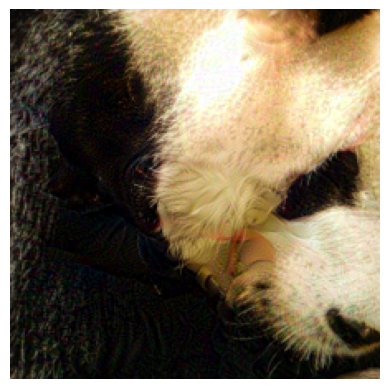

In [86]:
plt.imshow(adv_img)
plt.axis('off')
plt.show()

In [91]:
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# open_ai_key = user_secrets.get_secret("OPENAI_API_KEY")

In [93]:
# from openai import OpenAI

# client = OpenAI(api_key=open_ai_key)
# response = client.chat.completions.create(
#     model="gpt-4o",
#     messages=[{"role": "user", "content": "Hello, how can I use this API?"}],
# )

# print(response.choices[0].message.content)

Hello! I'd be happy to help you with that. However, I'll need more information about the specific API you're referring to. Generally speaking, to use an API, you can follow these steps:

1. **Understand the API Documentation**: Start by reviewing the API documentation provided by the service. This will give you a clear understanding of the endpoints, request methods (GET, POST, PUT, DELETE), request parameters, authentication methods, and the response format.

2. **Obtain API Access**: Many APIs require you to sign up for access or obtain an API key. Follow the provider's instructions to get your key or other required authentication credentials.

3. **Setting Up Your Development Environment**: Depending on the language you're using (Python, JavaScript, etc.), you'll need to set up your environment to make HTTP requests. You might use libraries like `requests` in Python, `axios` or `fetch` in JavaScript, etc.

4. **Making API Requests**:
   - **Endpoint**: Identify the API endpoint you 

In [ ]:
# prompt = f"""Rate the semantic similarity between the following two texts on a scale from 0 to 1.
        
#             **Criteria for similarity measurement:**
#             1. **Main Subject Consistency:** If both descriptions refer to the same key subject or object (e.g., a person, food, an event), they should receive a higher similarity score.
#             2. **Relevant Description**: If the descriptions are related to the same context or topic, they should also contribute to a higher similarity score.
#             3. **Ignore Fine-Grained Details:** Do not penalize differences in **phrasing, sentence structure, or minor variations in detail**. Focus on **whether both descriptions fundamentally describe the same thing.**
#             4. **Partial Matches:** If one description contains extra information but does not contradict the other, they should still have a high similarity score.
#             5. **Similarity Score Range:** 
#                 - **1.0**: Nearly identical in meaning.
#                 - **0.8-0.9**: Same subject, with highly related descriptions.
#                 - **0.7-0.8**: Same subject, core meaning aligned, even if some details differ.
#                 - **0.5-0.7**: Same subject but different perspectives or missing details.
#                 - **0.3-0.5**: Related but not highly similar (same general theme but different descriptions).
#                 - **0.0-0.2**: Completely different subjects or unrelated meanings.
                
#             Text 1: {text1}
#             Text 2: {text2}

#         Output only a single number between 0 and 1. Do not include any explanation or additional text."""

# response = client.chat.completions.create(
#     model=self.model,
#     messages=[{"role": "user", "content": prompt}],
#     max_tokens=100,
#     temperature=0.0,
# )
# score = response.choices[0].message.content.strip()
# print(min(1.0, max(0.0, float(score))))

In [ ]:
# Cell 12 — Preview and ZIP for Kaggle Output/download.
import matplotlib.pyplot as plt

def export_kaggle_zip(output_dir: Path = OUTPUT_DIR) -> Path:
    """Create a ZIP archive that Kaggle exposes under /kaggle/working Output."""
    if not (output_dir / 'manifest.jsonl').exists(): 
        raise FileNotFoundError('Run Cell 11 first.')
    return Path(shutil.make_archive(str(output_dir), 'zip', root_dir=output_dir))

if (OUTPUT_DIR / 'manifest.jsonl').exists():
    manifest_lines = [line for line in (OUTPUT_DIR / 'manifest.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
    if not manifest_lines:
        raise RuntimeError('Manifest is empty; no attack sample completed. Inspect status.json.')
    record = json.loads(manifest_lines[0])
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for axis, role in zip(axes, ('source', 'target', 'adversarial')):
        axis.imshow(Image.open(OUTPUT_DIR / record[role])); axis.set_title(role); axis.axis('off')
    plt.show()
    print('ZIP:', export_kaggle_zip())
else:
    print('No output yet. Run the attack cell first.')